# ANN Backpropagation Study

This notebook adds an explicit backpropagation-focused study for the hazard ANN.

It does not replace the main ANN pipeline. Instead, it retrains the same tabular hazard model while logging:
- train and validation loss
- total gradient norms
- first-layer and last-layer gradient norms
- weight update norms
- best epoch and clipped-gradient settings

Saved outputs are written to `models/ann/ann_backprop_results.json` so the dashboard can surface them.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pipelines").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pipelines.ann_hazard_pipeline import HazardAnn, build_tabular_dataset

OUTPUT_DIR = PROJECT_ROOT / "models" / "ann"
GRAPHS_DIR = OUTPUT_DIR / "graphs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
class TabDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx: int):
        return self.x[idx], self.y[idx]

df = build_tabular_dataset(samples_per_class=150, seed=42)
le_comp = LabelEncoder()
le_mat = LabelEncoder()
le_wc = LabelEncoder()
le_cond = LabelEncoder()
le_reg = LabelEncoder()
le_disp = LabelEncoder()

df["comp_enc"] = le_comp.fit_transform(df["component"])
df["mat_enc"] = le_mat.fit_transform(df["material_type"])
df["wc_enc"] = le_wc.fit_transform(df["weight_class"])
df["cond_enc"] = le_cond.fit_transform(df["condition"])
df["reg_enc"] = le_reg.fit_transform(df["region_risk"])
df["disp_enc"] = le_disp.fit_transform(df["disposal_history"])

features = [
    "comp_enc", "age_years", "weight_kg", "contains_lithium", "contains_lead",
    "contains_mercury", "contains_cadmium", "contains_cfc", "recyclable",
    "mat_enc", "wc_enc", "cond_enc", "reg_enc", "disp_enc",
]

x = df[features].values.astype(np.float32)
y = df["hazard_score"].values.astype(np.float32)

x_train, x_tmp, y_train, y_tmp = train_test_split(x, y, test_size=0.30, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_tmp, y_tmp, test_size=0.50, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

train_loader = DataLoader(TabDataset(x_train, y_train), batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(TabDataset(x_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(TabDataset(x_test, y_test), batch_size=64, shuffle=False)

model = HazardAnn(len(features), dropout=0.3).to(device)
criterion = nn.HuberLoss(delta=5.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

history = {
    "train_loss": [],
    "val_loss": [],
    "epochs": [],
    "total_grad_norm": [],
    "first_layer_grad_norm": [],
    "last_layer_grad_norm": [],
    "update_norm": [],
}

named_params = [(name, p) for name, p in model.named_parameters() if p.requires_grad]
first_param_name, first_param = named_params[0]
last_param_name, last_param = named_params[-1]

best_val = float("inf")
best_epoch = 0
best_state = None
clip_grad_norm = 1.0
patience = 25
patience_ctr = 0

In [3]:
for epoch in range(1, 161):
    model.train()
    train_loss = 0.0
    batch_total_grads = []
    batch_first_grads = []
    batch_last_grads = []
    batch_update_norms = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()

        total_sq = 0.0
        for _, param in named_params:
            if param.grad is None:
                continue
            grad_norm = param.grad.detach().norm(2).item()
            total_sq += grad_norm ** 2
        batch_total_grads.append(total_sq ** 0.5)
        batch_first_grads.append(first_param.grad.detach().norm(2).item())
        batch_last_grads.append(last_param.grad.detach().norm(2).item())

        pre_step_last = last_param.detach().clone()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        optimizer.step()
        batch_update_norms.append((last_param.detach() - pre_step_last).norm(2).item())
        train_loss += loss.item() * len(xb)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            val_loss += criterion(model(xb), yb).item() * len(xb)
    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    history["epochs"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["total_grad_norm"].append(float(np.mean(batch_total_grads)))
    history["first_layer_grad_norm"].append(float(np.mean(batch_first_grads)))
    history["last_layer_grad_norm"].append(float(np.mean(batch_last_grads)))
    history["update_norm"].append(float(np.mean(batch_update_norms)))

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"early stopping at epoch {epoch}")
            break

    if epoch % 20 == 0:
        print(f"epoch {epoch:03d} | train={train_loss:.4f} | val={val_loss:.4f} | grad={history['total_grad_norm'][-1]:.4f}")

model.load_state_dict(best_state)

epoch 020 | train=23.5362 | val=10.4123 | grad=92.2489
epoch 040 | train=22.2276 | val=11.4141 | grad=100.4545
epoch 060 | train=19.3941 | val=6.4705 | grad=82.8410
epoch 080 | train=17.6509 | val=6.4875 | grad=76.7906
epoch 100 | train=17.1991 | val=6.2135 | grad=78.4031
epoch 120 | train=18.6329 | val=6.2623 | grad=91.6378
early stopping at epoch 128


<All keys matched successfully>

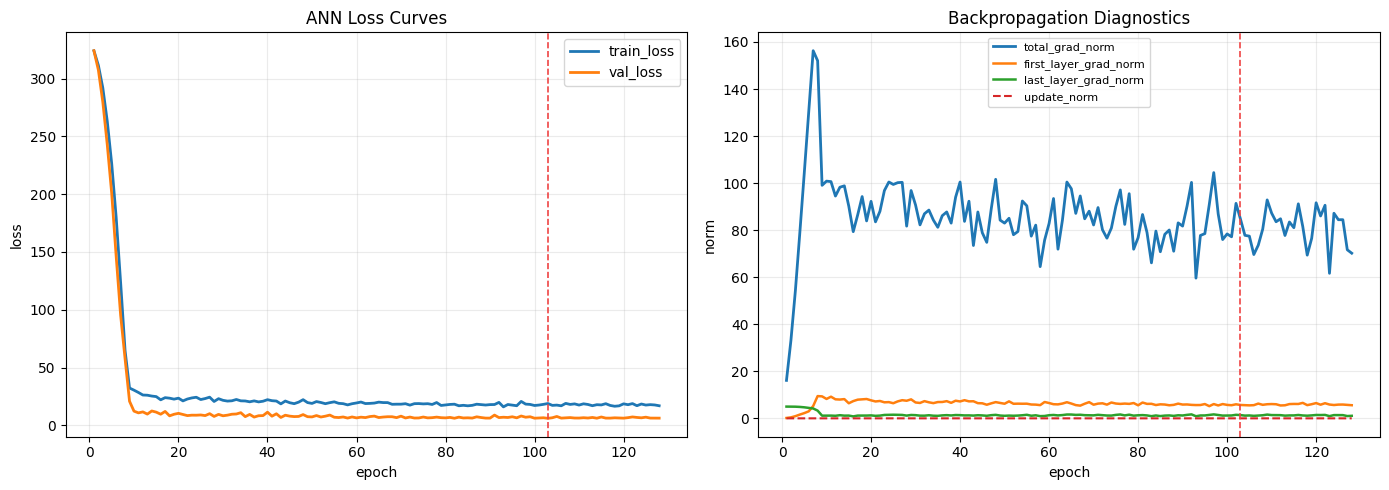

{'optimizer': 'AdamW',
 'loss': 'HuberLoss(delta=5.0)',
 'clip_grad_norm': 1.0,
 'best_epoch': 103,
 'best_val_loss': 6.087622835606704,
 'peak_total_grad_norm': 156.2793148590678,
 'mean_total_grad_norm': 85.37444613827702,
 'first_parameter': 'network.0.weight',
 'last_parameter': 'network.15.bias'}

In [4]:
model.eval()
pred, true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred.extend(model(xb).cpu().squeeze().numpy())
        true.extend(yb.squeeze().numpy())

pred = np.array(pred)
true = np.array(true)

results = {
    "model": "HazardAnn",
    "features": features,
    "best_epoch": int(best_epoch),
    "test_regression_metrics": {
        "mae": float(mean_absolute_error(true, pred)),
        "rmse": float(np.sqrt(mean_squared_error(true, pred))),
        "r2": float(r2_score(true, pred)),
    },
    "gradient_tracking": history,
    "backprop_summary": {
        "optimizer": "AdamW",
        "loss": "HuberLoss(delta=5.0)",
        "clip_grad_norm": clip_grad_norm,
        "best_epoch": int(best_epoch),
        "best_val_loss": float(best_val),
        "peak_total_grad_norm": float(np.max(history["total_grad_norm"])),
        "mean_total_grad_norm": float(np.mean(history["total_grad_norm"])),
        "first_parameter": first_param_name,
        "last_parameter": last_param_name,
    },
}

torch.save(best_state, OUTPUT_DIR / "ann_backprop_best_18cls.pth")
with (OUTPUT_DIR / "ann_backprop_results.json").open("w", encoding="utf-8") as fp:
    json.dump(results, fp, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["epochs"], history["train_loss"], label="train_loss", linewidth=2)
axes[0].plot(history["epochs"], history["val_loss"], label="val_loss", linewidth=2)
axes[0].axvline(best_epoch, linestyle="--", color="#ef4444", linewidth=1.2)
axes[0].set_title("ANN Loss Curves")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history["epochs"], history["total_grad_norm"], label="total_grad_norm", linewidth=2)
axes[1].plot(history["epochs"], history["first_layer_grad_norm"], label="first_layer_grad_norm", linewidth=1.8)
axes[1].plot(history["epochs"], history["last_layer_grad_norm"], label="last_layer_grad_norm", linewidth=1.8)
axes[1].plot(history["epochs"], history["update_norm"], label="update_norm", linewidth=1.5, linestyle="--")
axes[1].axvline(best_epoch, linestyle="--", color="#ef4444", linewidth=1.2)
axes[1].set_title("Backpropagation Diagnostics")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("norm")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(GRAPHS_DIR / "ann_backprop_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()

results["backprop_summary"]